K Means Clustering Algorithm Steps:

1. Choose K
2. Initialize centroids
3. Calculate distances
4. Assign clusters
5. Calculate new centroids
6. Repeat
7. Stop when centroids don't change

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
X = np.array([
    [1, 2],
    [2, 1],
    [2, 3],
    [3, 2],

    [8, 8],
    [9, 7],
    [8, 9],
    [10, 8],

    [4, 8],
    [5, 9],
    [5, 7],
    [6, 8]
])

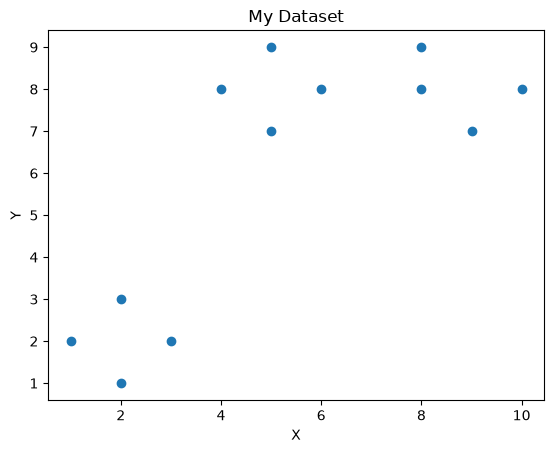

In [5]:
plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("X")
plt.ylabel("Y")
plt.title("My Dataset")

plt.show()

In [6]:
K = 3 #assuming initial cluster is 3

In [7]:
centroids = np.array([
    [1, 2],
    [8, 8],
    [5, 8]
], dtype=float)

In [8]:
def euclidean_distance(point, centroid):
    distance = np.sqrt(
        (point[0] - centroid[0]) ** 2 +
        (point[1] - centroid[1]) ** 2
    )

    return distance

In [9]:
#test the distance is correctly calculated or not
point = np.array([2, 1])
centroid = np.array([1, 2])

distance = euclidean_distance(point, centroid)

print(distance)



1.4142135623730951


In [10]:
def assign_clusters(X, centroids):

    clusters = []

    for point in X:

        distances = []

        for centroid in centroids:

            distance = euclidean_distance(point, centroid)

            distances.append(distance)

        nearest_cluster = np.argmin(distances)

        clusters.append(nearest_cluster)

    return np.array(clusters)

In [11]:
clusters = assign_clusters(X, centroids)

print(clusters)

[0 0 0 0 1 1 1 1 2 2 2 2]


In [12]:
def calculate_centroids(X, clusters, K):

    new_centroids = []

    for cluster_number in range(K):

        cluster_points = X[clusters == cluster_number]

        centroid = np.mean(cluster_points, axis=0)

        new_centroids.append(centroid)

    return np.array(new_centroids)

In [14]:
for iteration in range(100):

    clusters = assign_clusters(X, centroids)

    new_centroids = calculate_centroids(
        X,
        clusters,
        K
    )

    if np.allclose(centroids, new_centroids):

        print("Cover")

        break

    centroids = new_centroids


Cover


In [15]:
print("Final centroids:")
print(centroids)

print("Cluster assignments:")
print(clusters)

Final centroids:
[[2.   2.  ]
 [8.75 8.  ]
 [5.   8.  ]]
Cluster assignments:
[0 0 0 0 1 1 1 1 2 2 2 2]


In [ ]:
print("Final centroids:")
print(centroids)

print("Cluster assignments:")
print(clusters)

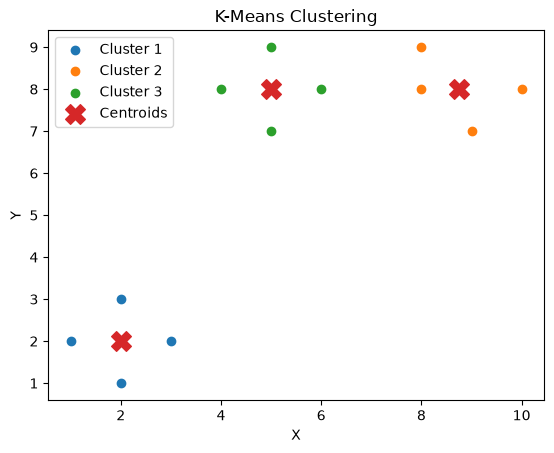

In [16]:
for cluster_number in range(K):

    cluster_points = X[clusters == cluster_number]

    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        label=f"Cluster {cluster_number + 1}"
    )


plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("K-Means Clustering")

plt.legend()
plt.show()

## 26. The entire algorithm in mathematical form

### Step 1 — Initialize
Choose $K$ centroids:

$$
C_1, C_2, \dots, C_K
$$

### Step 2 — Assignment
For every point $x_i$, calculate:

$$
d(x_i, C_j) = \sqrt{ \sum_{m=1}^{n} (x_{im} - C_{jm})^2 }
$$

Then assign $x_i$ to the nearest centroid:

$$
Cluster(x_i) = \arg\min_j \, d(x_i, C_j)
$$

### Step 3 — Update
For every cluster, calculate the mean:

$$
C_j = \frac{1}{|S_j|} \sum_{x_i \in S_j} x_i
$$

where $S_j$ is the set of points assigned to cluster $j$.

### Step 4 — Repeat
Repeat:

$$
Assignment \rightarrow Update \rightarrow Assignment \rightarrow Update
$$

until the centroids stop changing.